In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo visual
plt.style.use("ggplot")

print("✅ Setup listo")

✅ Setup listo


In [61]:
df = pd.read_csv("../data/processed/ventas_historico.csv")

# Convertir a datetime (por seguridad)
df["fecha"] = pd.to_datetime(df["fecha"])

ultima_fecha = df["fecha"].max()

print(f"📊 Dataset actualizado hasta el {ultima_fecha.strftime('%d/%m/%Y')} | Registros: {len(df)}")

📊 Dataset actualizado hasta el 23/05/2026 | Registros: 1565


In [40]:
# KPIs principales
kpi_total_ventas = df["ventas"].sum()
kpi_prom_venta = df["ventas"].mean()
kpi_dias = df["fecha"].nunique()
kpi_registros = len(df)

# KPI: % ventas sobre promedio (si existe la columna)
if "venta_sobre_prom_producto" in df.columns:
    kpi_pct_sobre_prom = df["venta_sobre_prom_producto"].mean()
else:
    kpi_pct_sobre_prom = np.nan

print("📌 KPIs principales")
print(f"• Total ventas: {kpi_total_ventas:,.0f}")
print(f"• Promedio por registro: {kpi_prom_venta:,.2f}")
print(f"• Días en histórico: {kpi_dias}")
print(f"• Registros: {kpi_registros:,}")
if not np.isnan(kpi_pct_sobre_prom):
    print(f"• % ventas sobre promedio (producto): {kpi_pct_sobre_prom:.1%}")


📌 KPIs principales
• Total ventas: 991,037
• Promedio por registro: 1,248.16
• Días en histórico: 4
• Registros: 794
• % ventas sobre promedio (producto): 50.9%


In [57]:
# Ventas por producto / región
ventas_producto = df.groupby("producto")["ventas"].sum().sort_values(ascending=False)
ventas_region = df.groupby("region")["ventas"].sum().sort_values(ascending=False)

# Tendencia diaria
ventas_dia = df.groupby("fecha")["ventas"].sum().sort_index()

# KPI de performance: % sobre promedio por producto (si existe)
pct_sobre_prod = None
if "venta_sobre_prom_producto" in df.columns:
    pct_sobre_prod = df.groupby("producto")["venta_sobre_prom_producto"].mean().sort_values(ascending=False)

ventas_producto, ventas_region, ventas_dia.head()

(producto
 C    721495
 A    640686
 B    590040
 Name: ventas, dtype: int64,
 region
 Centro    700153
 Norte     666010
 Sur       586058
 Name: ventas, dtype: int64,
 fecha
 2026-05-19    248134
 2026-05-20    252314
 2026-05-21    248198
 2026-05-22    958394
 2026-05-23    245181
 Name: ventas, dtype: int64)

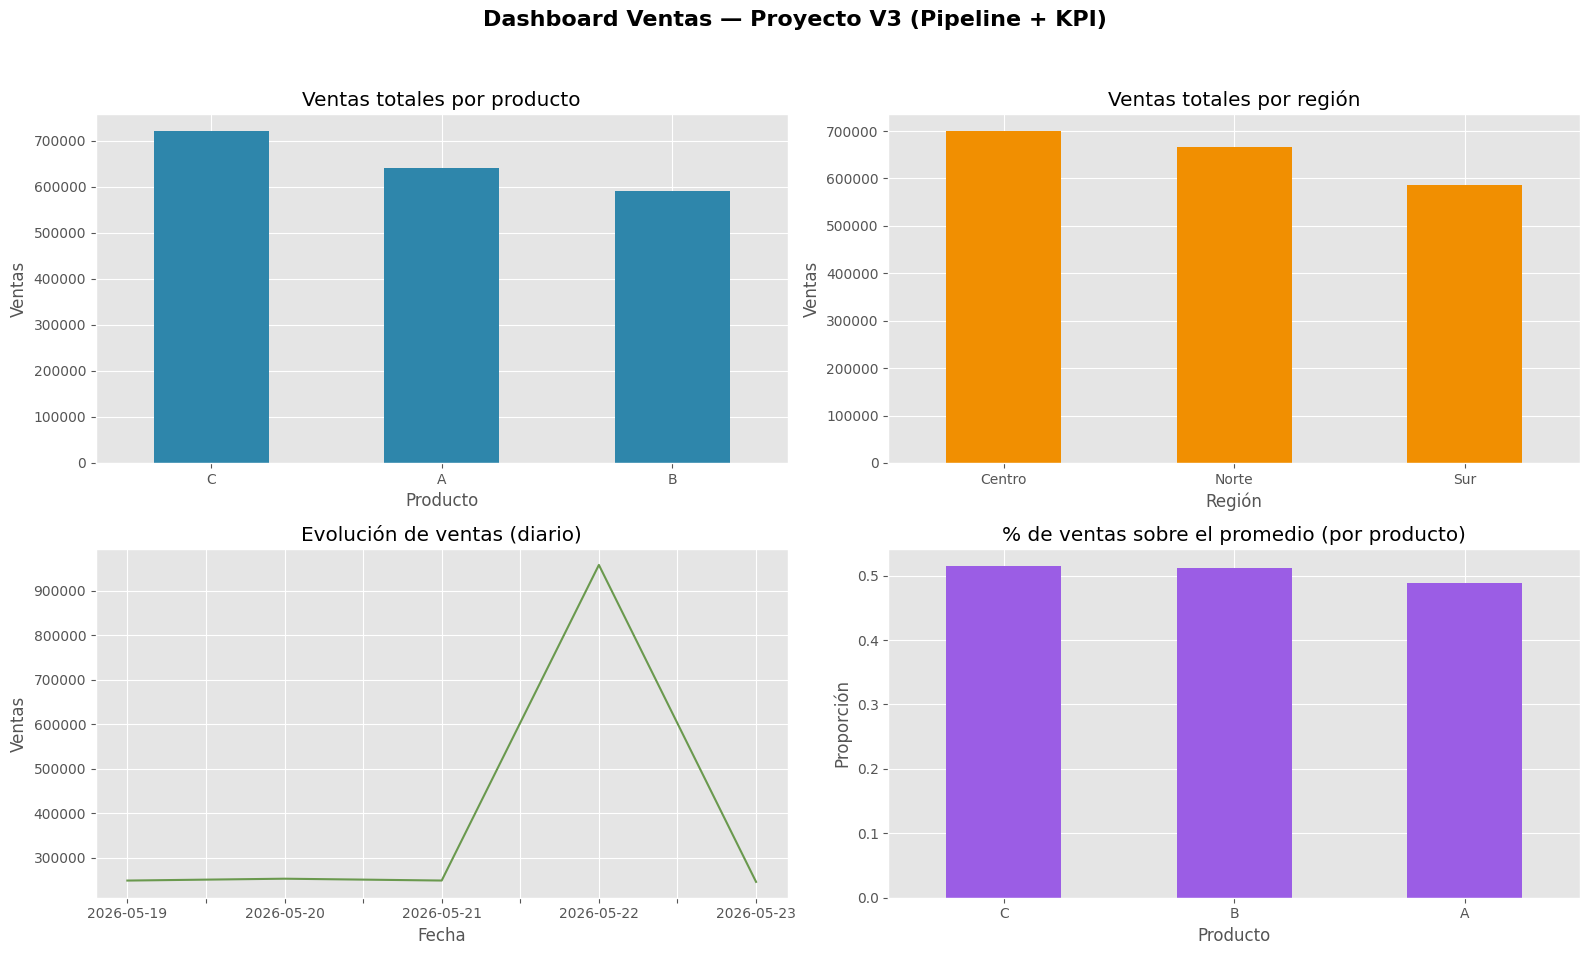

In [58]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Dashboard Ventas — Proyecto V3 (Pipeline + KPI)", fontsize=16, fontweight="bold")

# 1) Ventas por producto
ventas_producto.plot(kind="bar", ax=axs[0, 0], color="#2E86AB")
axs[0, 0].set_title("Ventas totales por producto")
axs[0, 0].set_xlabel("Producto")
axs[0, 0].set_ylabel("Ventas")
axs[0, 0].tick_params(axis="x", rotation=0)

# 2) Ventas por región
ventas_region.plot(kind="bar", ax=axs[0, 1], color="#F18F01")
axs[0, 1].set_title("Ventas totales por región")
axs[0, 1].set_xlabel("Región")
axs[0, 1].set_ylabel("Ventas")
axs[0, 1].tick_params(axis="x", rotation=0)

# 3) Tendencia diaria
ventas_dia.plot(ax=axs[1, 0], color="#6A994E")
axs[1, 0].set_title("Evolución de ventas (diario)")
axs[1, 0].set_xlabel("Fecha")
axs[1, 0].set_ylabel("Ventas")

# 4) % sobre promedio por producto (si existe)
axs[1, 1].axis("off")
if pct_sobre_prod is not None:
    axs[1, 1].axis("on")
    pct_sobre_prod.plot(kind="bar", ax=axs[1, 1], color="#9B5DE5")
    axs[1, 1].set_title("% de ventas sobre el promedio (por producto)")
    axs[1, 1].set_xlabel("Producto")
    axs[1, 1].set_ylabel("Proporción")
    axs[1, 1].tick_params(axis="x", rotation=0)
else:
    axs[1, 1].text(0.1, 0.5, "No existe columna 'venta_sobre_prom_producto'\n(Generá KPIs y volvemos a graficar).",
                   fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [33]:
top_prod = ventas_producto.index[0]
top_prod_val = ventas_producto.iloc[0]

top_reg = ventas_region.index[0]
top_reg_val = ventas_region.iloc[0]

ultimo_dia = ventas_dia.index.max()
ventas_ultimo = ventas_dia.loc[ultimo_dia]

print("🧠 Insights rápidos (auto)")
print(f"• Producto líder por ventas: {top_prod} ({top_prod_val:,.0f})")
print(f"• Región líder por ventas: {top_reg} ({top_reg_val:,.0f})")
print(f"• Ventas del último día ({ultimo_dia.date()}): {ventas_ultimo:,.0f}")

if pct_sobre_prod is not None:
    best_perf = pct_sobre_prod.index[0]
    best_perf_val = pct_sobre_prod.iloc[0]
    print(f"• Mejor performance relativa (% sobre promedio): {best_perf} ({best_perf_val:.1%})")

🧠 Insights rápidos (auto)
• Producto líder por ventas: C (384,860)
• Región líder por ventas: Centro (358,304)
• Ventas del último día (2026-05-22): 242,391
• Mejor performance relativa (% sobre promedio): C (51.6%)


In [51]:
from pathlib import Path

ruta = Path("../data/processed/ventas_historico.csv")
df = pd.read_csv(ruta)

# Tipos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Chequeos básicos
cols_necesarias = {"fecha", "region", "producto", "ventas"}
faltan = cols_necesarias - set(df.columns)
if faltan:
    raise ValueError(f"Faltan columnas en el histórico: {faltan}")

# Asegurar ventas numéricas
df["ventas"] = pd.to_numeric(df["ventas"], errors="coerce")

# Filtrar filas inválidas (portfolio-friendly: mejor que explote por NaN)
df = df.dropna(subset=["fecha", "ventas", "region", "producto"])

df.head()

,fecha,region,producto,ventas,promedio_producto,venta_sobre_prom_producto,promedio_region,venta_sobre_prom_region
0,2026-05-19,Centro,A,1813,1256.247059,True,1266.099458,True
1,2026-05-19,Sur,C,1290,1235.436644,True,1239.023256,True
2,2026-05-19,Centro,B,711,1252.738854,False,1266.099458,False
3,2026-05-19,Norte,C,1412,1235.436644,True,1235.640074,True
4,2026-05-19,Sur,C,1858,1235.436644,True,1239.023256,True


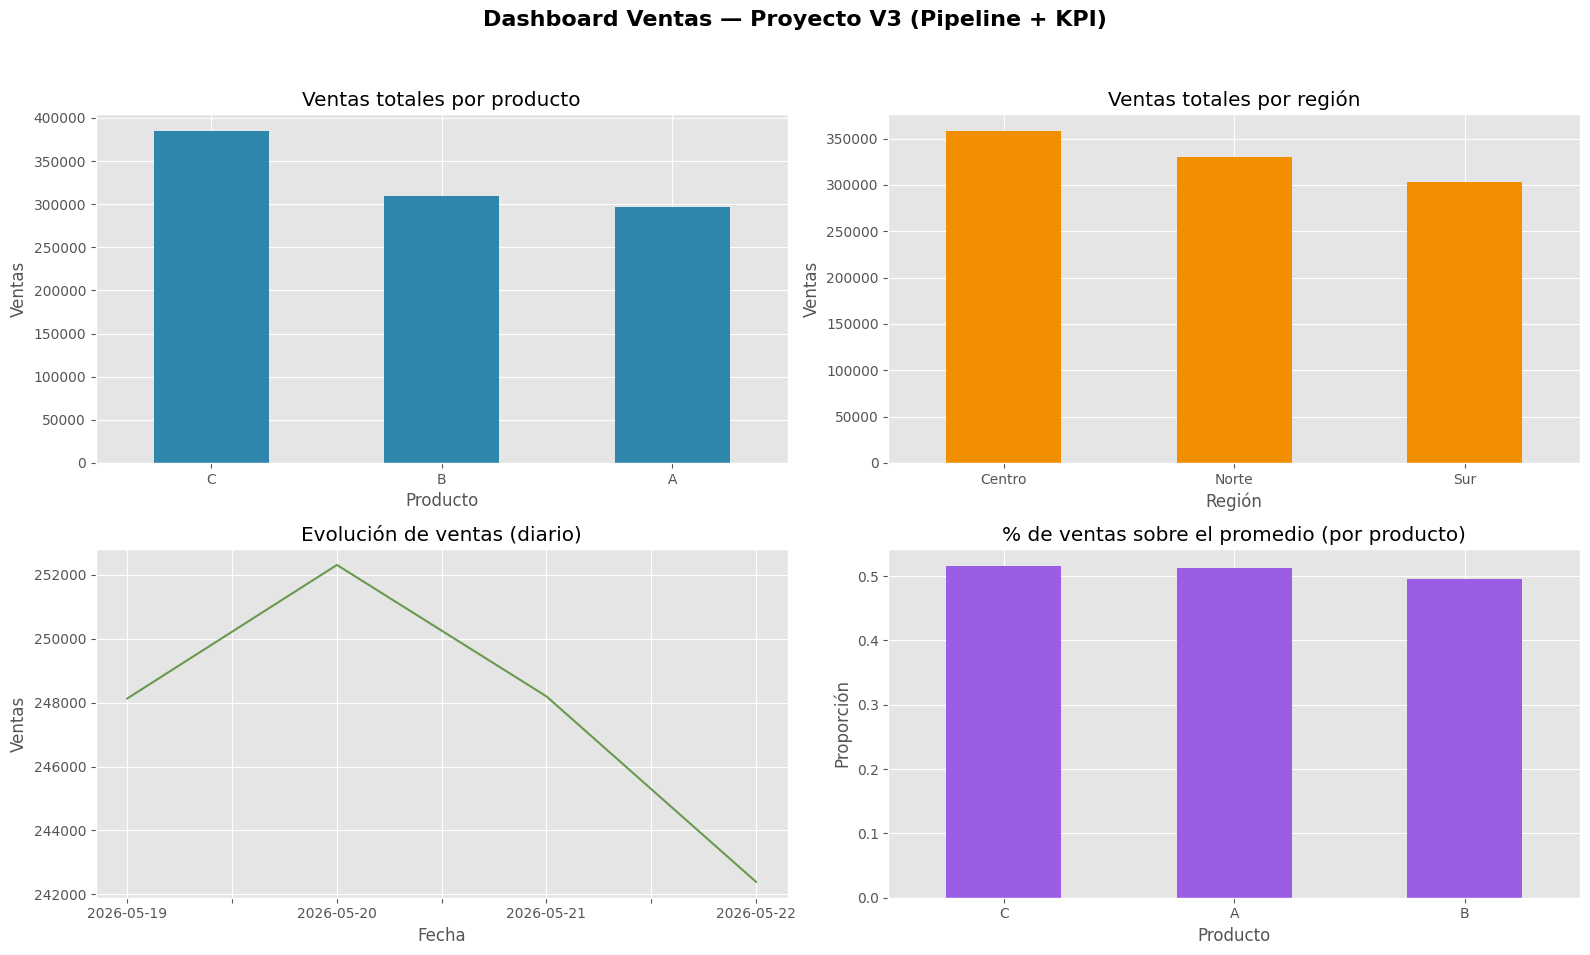

✅ Guardado: output/dashboard_v3.png


In [52]:
# Re-ejecuta el dashboard y guárdalo como PNG
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Dashboard Ventas — Proyecto V3 (Pipeline + KPI)", fontsize=16, fontweight="bold")

ventas_producto.plot(kind="bar", ax=axs[0, 0], color="#2E86AB")
axs[0, 0].set_title("Ventas totales por producto")
axs[0, 0].set_xlabel("Producto")
axs[0, 0].set_ylabel("Ventas")
axs[0, 0].tick_params(axis="x", rotation=0)

ventas_region.plot(kind="bar", ax=axs[0, 1], color="#F18F01")
axs[0, 1].set_title("Ventas totales por región")
axs[0, 1].set_xlabel("Región")
axs[0, 1].set_ylabel("Ventas")
axs[0, 1].tick_params(axis="x", rotation=0)

ventas_dia.plot(ax=axs[1, 0], color="#6A994E")
axs[1, 0].set_title("Evolución de ventas (diario)")
axs[1, 0].set_xlabel("Fecha")
axs[1, 0].set_ylabel("Ventas")

axs[1, 1].axis("off")
if pct_sobre_prod is not None:
    axs[1, 1].axis("on")
    pct_sobre_prod.plot(kind="bar", ax=axs[1, 1], color="#9B5DE5")
    axs[1, 1].set_title("% de ventas sobre el promedio (por producto)")
    axs[1, 1].set_xlabel("Producto")
    axs[1, 1].set_ylabel("Proporción")
    axs[1, 1].tick_params(axis="x", rotation=0)
else:
    axs[1, 1].text(0.1, 0.5, "Sin KPI 'venta_sobre_prom_producto'", fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Guardar
Path("../output").mkdir(exist_ok=True)
plt.savefig("../output/dashboard_v3.png", dpi=200)
plt.show()

print("✅ Guardado: output/dashboard_v3.png")

In [53]:
import sys
import os
sys.path.append("../src")

from generate_daily import generar_datos_dia

df_test = generar_datos_dia("2026-05-19")

df_test.head()

,fecha,region,producto,ventas
0,2026-05-19,Norte,C,1442
1,2026-05-19,Centro,B,966
2,2026-05-19,Centro,B,1779
3,2026-05-19,Sur,A,1835
4,2026-05-19,Sur,B,630


In [36]:
df = pd.read_csv("../data/processed/ventas_historico.csv")

In [37]:
import pandas as pd

df = pd.read_csv("../data/processed/ventas_historico.csv")

print("Filas y columnas:", df.shape)
print("Fecha mínima:", df["fecha"].min())
print("Fecha máxima:", df["fecha"].max())


Filas y columnas: (794, 8)
Fecha mínima: 2026-05-19
Fecha máxima: 2026-05-22


In [15]:
import os
print(os.getcwd())


c:\Users\Usuario\OneDrive\Documentos\python_practica\analisis-ventas-python\notebooks


In [16]:
# ver estructura
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 794 entries, 0 to 793
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   fecha                      794 non-null    str    
 1   region                     794 non-null    str    
 2   producto                   794 non-null    str    
 3   ventas                     794 non-null    int64  
 4   promedio_producto          794 non-null    float64
 5   venta_sobre_prom_producto  794 non-null    bool   
 6   promedio_region            794 non-null    float64
 7   venta_sobre_prom_region    794 non-null    bool   
dtypes: bool(2), float64(2), int64(1), str(3)
memory usage: 38.9 KB


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["fecha"].value_counts()


fecha
2026-05-21    200
2026-05-19    198
2026-05-20    198
2026-05-22    198
Name: count, dtype: int64

In [19]:
df.groupby("producto")["venta_sobre_prom_producto"].mean()

producto
A    0.512931
B    0.496032
C    0.516129
Name: venta_sobre_prom_producto, dtype: float64

In [20]:
import pandas as pd

df = pd.read_csv("../data/processed/ventas_historico.csv")

print("Filas, columnas:", df.shape)
print("Min fecha:", df["fecha"].min())
print("Max fecha:", df["fecha"].max())

df.head()

Filas, columnas: (794, 8)
Min fecha: 2026-05-19
Max fecha: 2026-05-22


,fecha,region,producto,ventas,promedio_producto,venta_sobre_prom_producto,promedio_region,venta_sobre_prom_region
0,2026-05-19,Centro,A,1813,1278.982759,True,1279.657143,True
1,2026-05-19,Sur,C,1290,1241.483871,True,1226.510121,True
2,2026-05-19,Centro,B,711,1227.988095,False,1279.657143,False
3,2026-05-19,Norte,C,1412,1241.483871,True,1235.149813,True
4,2026-05-19,Sur,C,1858,1241.483871,True,1226.510121,True


In [21]:
df.columns

Index(['fecha', 'region', 'producto', 'ventas', 'promedio_producto',
       'venta_sobre_prom_producto', 'promedio_region',
       'venta_sobre_prom_region'],
      dtype='str')

In [22]:
df[["producto","ventas","promedio_producto","venta_sobre_prom_producto"]].head(10)


,producto,ventas,promedio_producto,venta_sobre_prom_producto
0,A,1813,1278.982759,True
1,C,1290,1241.483871,True
2,B,711,1227.988095,False
3,C,1412,1241.483871,True
4,C,1858,1241.483871,True
5,B,667,1227.988095,False
6,C,1586,1241.483871,True
7,C,622,1241.483871,False
8,C,1137,1241.483871,False
9,A,1408,1278.982759,True


In [23]:
import pandas as pd

df = pd.read_csv("../data/processed/ventas_historico.csv")

df.head()

,fecha,region,producto,ventas,promedio_producto,venta_sobre_prom_producto,promedio_region,venta_sobre_prom_region
0,2026-05-19,Centro,A,1813,1278.982759,True,1279.657143,True
1,2026-05-19,Sur,C,1290,1241.483871,True,1226.510121,True
2,2026-05-19,Centro,B,711,1227.988095,False,1279.657143,False
3,2026-05-19,Norte,C,1412,1241.483871,True,1235.149813,True
4,2026-05-19,Sur,C,1858,1241.483871,True,1226.510121,True


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/ventas_historico.csv")

# aseguramos formato de fecha
df["fecha"] = pd.to_datetime(df["fecha"])

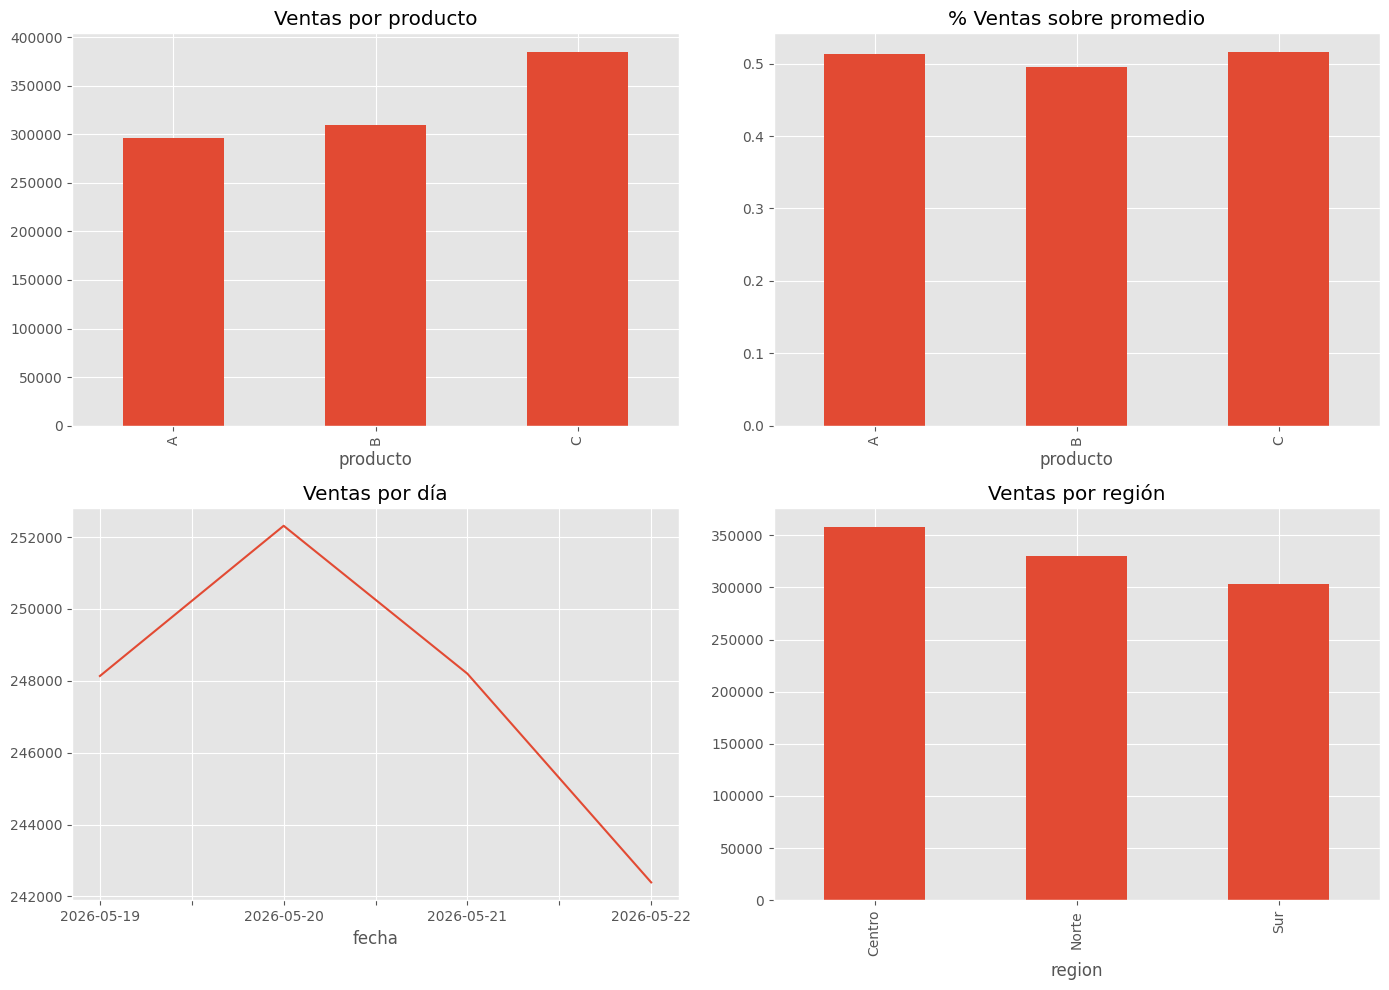

In [38]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

plt.style.use("ggplot")

# 1. Ventas totales por producto
df.groupby("producto")["ventas"].sum().plot(
    kind="bar", ax=axs[0,0], title="Ventas por producto"
)

# 2. KPI: % ventas sobre promedio
df.groupby("producto")["venta_sobre_prom_producto"].mean().plot(
    kind="bar", ax=axs[0,1], title="% Ventas sobre promedio"
)

# 3. Ventas por día (tendencia)
df.groupby("fecha")["ventas"].sum().plot(
    ax=axs[1,0], title="Ventas por día"
)

# 4. Ventas por región
df.groupby("region")["ventas"].sum().plot(
    kind="bar", ax=axs[1,1], title="Ventas por región"
)

plt.tight_layout()
plt.show()

In [39]:
# Crear dataset modelo para Power BI
cols_modelo = [
    "fecha",
    "region",
    "producto",
    "ventas",
    "promedio_producto",
    "venta_sobre_prom_producto",
    "promedio_region",
    "venta_sobre_prom_region"
]

modelo = df[cols_modelo].copy()

# Guardar archivo
modelo.to_csv("../output/modelo_dashboard.csv", index=False)

print("✅ Archivo modelo_dashboard.csv generado")

✅ Archivo modelo_dashboard.csv generado
